# DQN #2

In [17]:
import sys
!{sys.executable} -m pip install "gymnasium[box2d]" tqdm

In [32]:
import torch
import sys
import os
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("Torch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Python: D:\Python\RL\-project_1303_dqn2\.venv\Scripts\python.exe
Torch: 2.11.0+cu128
Torch CUDA: 12.8
CUDA available: True
Device count: 1
NVIDIA GeForce RTX 5080


In [19]:
import random
import ast
import json
import pickle
from collections import deque
from copy import deepcopy
from pathlib import Path

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm



def make_pbar(total, desc, unit="ep", leave=True):
    return tqdm(total=total, desc=desc, unit=unit, dynamic_ncols=True, leave=leave)


def update_pbar(pbar, reward=None, avg=None, eps=None):
    if pbar is None:
        return
    postfix = {}
    if reward is not None:
        postfix["R"] = f"{reward:.1f}"
    if avg is not None:
        postfix["avg20"] = f"{avg:.1f}"
    if eps is not None:
        postfix["eps"] = f"{eps:.3f}"
    if postfix:
        pbar.set_postfix(postfix)
    pbar.update(1)


if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)




SAVE_DIR = Path("saved_results") # хранит уже полностью завершённые запуски
SAVE_DIR.mkdir(exist_ok=True) # хранит незавершённые запуски и позволяет продолжить обучение с середины

CHECKPOINT_DIR = SAVE_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)


USE_CHECKPOINTS = True  # Если True, то обучение продолжается с checkpoint


CHECKPOINT_EVERY = 20   # Как частота checkpoint во время обучения


FORCE_RERUN = False     # Если True, то готовые результаты и checkpoint игнорируются, всё считается заново


Device: cuda


In [20]:
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


def make_env(env_name, seed=None):
    try:
        env = gym.make(env_name)
    except Exception:
        if env_name == "LunarLander-v3":
            print("LunarLander-v3 не найден, пробую LunarLander-v2")
            env = gym.make("LunarLander-v2")
        else:
            raise

    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    return env


def moving_average(values, window=10):
    return pd.Series(values).rolling(window, min_periods=1).mean().to_numpy()


def mountain_car_potential(state):
    return 300.0 * abs(float(state[1]))


def apply_reward_shaping(env_name, state, next_state, reward, done, gamma, enabled=True):
    if not enabled:
        return reward
    if env_name != "MountainCar-v0":
        return reward

    phi_state = mountain_car_potential(state)
    phi_next = 0.0 if done else mountain_car_potential(next_state)
    return reward + gamma * phi_next - phi_state


def normalize_observation(state, env_name, enabled=False):
    if not enabled or env_name != "MountainCar-v0":
        return np.asarray(state, dtype=np.float32)

    low = np.array([-1.2, -0.07], dtype=np.float32)
    high = np.array([0.6, 0.07], dtype=np.float32)
    return 2.0 * (np.asarray(state, dtype=np.float32) - low) / (high - low) - 1.0


def shape_reward_c51(env_name, state, action, reward, next_state, done, enabled=False):
    if not enabled or env_name != "MountainCar-v0":
        return reward

    position, velocity = next_state
    shaped = reward
    shaped += 10.0 * abs(float(velocity))
    shaped += 0.5 * (float(position) + 0.5)

    if (action == 2 and velocity > 0) or (action == 0 and velocity < 0):
        shaped += 0.2

    if done and position >= 0.5:
        shaped += 20.0

    return min(0.0, shaped)


In [21]:
def safe_name(text):
    return str(text).replace("/", "_").replace("\\", "_").replace(":", "_").replace(" ", "_")


def make_checkpoint_path(env_name, alg_name):
    return CHECKPOINT_DIR / f"{safe_name(env_name)}__{safe_name(alg_name)}.pt"


def make_checkpoint_meta_path(env_name, alg_name):
    return CHECKPOINT_DIR / f"{safe_name(env_name)}__{safe_name(alg_name)}.json"


def to_cpu_tree(obj):
    if torch.is_tensor(obj):
        return obj.detach().cpu()
    if isinstance(obj, dict):
        return {k: to_cpu_tree(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_cpu_tree(v) for v in obj]
    if isinstance(obj, tuple):
        return tuple(to_cpu_tree(v) for v in obj)
    return obj


def move_optimizer_state_to_device(optimizer, device):
    for state in optimizer.state.values():
        for key, value in list(state.items()):
            if torch.is_tensor(value):
                state[key] = value.to(device)


def checkpoint_pickle_save(obj, path):
    with open(path, "wb") as f:
        pickle.dump(to_cpu_tree(obj), f, protocol=pickle.HIGHEST_PROTOCOL)
        f.flush()
        try:
            os.fsync(f.fileno())
        except Exception:
            pass


def torch_load_checkpoint(path):
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception as pickle_error:
        try:
            return torch.load(path, map_location=DEVICE, weights_only=False)
        except TypeError:
            return torch.load(path, map_location=DEVICE)
        except Exception:
            raise pickle_error


def atomic_torch_save(obj, path):
    tmp_path = path.with_name(path.name + ".tmp")
    if tmp_path.exists():
        tmp_path.unlink()
    checkpoint_pickle_save(obj, tmp_path)
    tmp_path.replace(path)


def write_checkpoint_meta(env_name, alg_name, episode):
    meta_path = make_checkpoint_meta_path(env_name, alg_name)
    tmp_meta_path = meta_path.with_name(meta_path.name + ".tmp")
    with open(tmp_meta_path, "w", encoding="utf-8") as f:
        json.dump({"env_name": env_name, "alg_name": alg_name, "episode": int(episode)}, f, ensure_ascii=False, indent=2)
        f.flush()
        try:
            os.fsync(f.fileno())
        except Exception:
            pass
    tmp_meta_path.replace(meta_path)


def quarantine_bad_checkpoint(env_name, alg_name, error):
    checkpoint_path = make_checkpoint_path(env_name, alg_name)
    meta_path = make_checkpoint_meta_path(env_name, alg_name)

    print(f"Checkpoint повреждён и будет пропущен: {checkpoint_path}")
    print(f"Причина: {type(error).__name__}: {error}")

    if checkpoint_path.exists():
        broken_path = checkpoint_path.with_name(checkpoint_path.name + ".broken")
        if broken_path.exists():
            broken_path.unlink()
        try:
            checkpoint_path.replace(broken_path)
            print(f"Битый checkpoint перенесён в: {broken_path}")
        except Exception:
            checkpoint_path.unlink()
            print("Битый checkpoint удалён.")

    tmp_path = checkpoint_path.with_name(checkpoint_path.name + ".tmp")
    if tmp_path.exists():
        try:
            tmp_path.unlink()
        except Exception:
            pass

    if meta_path.exists():
        meta_path.unlink()


def get_checkpoint_episode(env_name, alg_name):
    if not USE_CHECKPOINTS or FORCE_RERUN:
        return 0

    meta_path = make_checkpoint_meta_path(env_name, alg_name)
    checkpoint_path = make_checkpoint_path(env_name, alg_name)

    if not checkpoint_path.exists() or checkpoint_path.stat().st_size == 0:
        if meta_path.exists():
            meta_path.unlink()
        if checkpoint_path.exists():
            checkpoint_path.unlink()
        return 0

    if meta_path.exists():
        try:
            with open(meta_path, "r", encoding="utf-8") as f:
                return int(json.load(f).get("episode", 0))
        except Exception:
            return 0

    if checkpoint_path.exists():
        try:
            checkpoint = torch_load_checkpoint(checkpoint_path)
            return int(checkpoint.get("episode", 0))
        except Exception as e:
            quarantine_bad_checkpoint(env_name, alg_name, e)
            return 0

    return 0


def remove_checkpoint(env_name, alg_name):
    checkpoint_path = make_checkpoint_path(env_name, alg_name)
    meta_path = make_checkpoint_meta_path(env_name, alg_name)
    tmp_path = checkpoint_path.with_name(checkpoint_path.name + ".tmp")

    for path in (checkpoint_path, meta_path, tmp_path):
        if path.exists():
            try:
                path.unlink()
            except Exception:
                pass


def save_dqn_checkpoint(env_name, alg_name, episode, agent, replay_buffer, rewards_history, losses_history, config):
    if not USE_CHECKPOINTS:
        return

    checkpoint_path = make_checkpoint_path(env_name, alg_name)
    try:
        atomic_torch_save({
            "kind": "dqn",
            "env_name": env_name,
            "alg_name": alg_name,
            "episode": int(episode),
            "q_net": agent.q_net.state_dict(),
            "target_net": agent.target_net.state_dict(),
            "optimizer": agent.optimizer.state_dict(),
            "epsilon": float(agent.epsilon),
            "global_step": int(agent.global_step),
            "replay_buffer": replay_buffer,
            "rewards_history": rewards_history,
            "losses_history": losses_history,
            "config": deepcopy(config),
        }, checkpoint_path)
        write_checkpoint_meta(env_name, alg_name, episode)
    except Exception as e:
        print(f"Не удалось сохранить checkpoint {checkpoint_path}: {type(e).__name__}: {e}")


def load_dqn_checkpoint(env_name, alg_name, agent):
    checkpoint_path = make_checkpoint_path(env_name, alg_name)
    if not USE_CHECKPOINTS or FORCE_RERUN or not checkpoint_path.exists():
        return None

    try:
        checkpoint = torch_load_checkpoint(checkpoint_path)
    except Exception as e:
        quarantine_bad_checkpoint(env_name, alg_name, e)
        return None

    agent.q_net.load_state_dict(checkpoint["q_net"])
    agent.target_net.load_state_dict(checkpoint["target_net"])
    agent.optimizer.load_state_dict(checkpoint["optimizer"])
    move_optimizer_state_to_device(agent.optimizer, DEVICE)
    agent.epsilon = float(checkpoint["epsilon"])
    agent.global_step = int(checkpoint.get("global_step", 0))
    print(f"Загружен checkpoint: {checkpoint_path}, продолжаем с episode={int(checkpoint['episode']) + 1}")
    return checkpoint


def save_c51_checkpoint(
    env_name,
    alg_name,
    episode,
    policy_net,
    target_net,
    optimizer,
    replay_buffer,
    rewards_history,
    losses_history,
    epsilon,
    global_step,
    config,
):
    if not USE_CHECKPOINTS:
        return

    checkpoint_path = make_checkpoint_path(env_name, alg_name)
    try:
        atomic_torch_save({
            "kind": "c51",
            "env_name": env_name,
            "alg_name": alg_name,
            "episode": int(episode),
            "policy_net": policy_net.state_dict(),
            "target_net": target_net.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epsilon": float(epsilon),
            "global_step": int(global_step),
            "replay_buffer": replay_buffer,
            "rewards_history": rewards_history,
            "losses_history": losses_history,
            "config": deepcopy(config),
        }, checkpoint_path)
        write_checkpoint_meta(env_name, alg_name, episode)
    except Exception as e:
        print(f"Не удалось сохранить checkpoint {checkpoint_path}: {type(e).__name__}: {e}")


def load_c51_checkpoint(env_name, alg_name, policy_net, target_net, optimizer):
    checkpoint_path = make_checkpoint_path(env_name, alg_name)
    if not USE_CHECKPOINTS or FORCE_RERUN or not checkpoint_path.exists():
        return None

    try:
        checkpoint = torch_load_checkpoint(checkpoint_path)
    except Exception as e:
        quarantine_bad_checkpoint(env_name, alg_name, e)
        return None

    policy_net.load_state_dict(checkpoint["policy_net"])
    target_net.load_state_dict(checkpoint["target_net"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    move_optimizer_state_to_device(optimizer, DEVICE)
    print(f"Загружен checkpoint: {checkpoint_path}, продолжаем с episode={int(checkpoint['episode']) + 1}")
    return checkpoint


## Общий replay buffer

In [22]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.buffer = []
        self.pos = 0

    def add(self, state, action, reward, next_state, done, discount):
        item = (state, action, reward, next_state, done, discount)
        if len(self.buffer) < self.capacity:
            self.buffer.append(item)
        else:
            self.buffer[self.pos] = item
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        batch_size = int(batch_size)
        idxs = np.random.choice(len(self.buffer), size=batch_size, replace=False)
        batch = [self.buffer[i] for i in idxs]
        states, actions, rewards, next_states, dones, discounts = zip(*batch)
        return (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(dones, dtype=np.float32),
            np.asarray(discounts, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


class NStepCollector:
    def __init__(self, n_step, gamma):
        self.n_step = n_step
        self.gamma = gamma
        self.queue = deque()

    def reset(self):
        self.queue.clear()

    def _make_transition(self):
        state, action = self.queue[0][0], self.queue[0][1]
        total_reward = 0.0
        next_state = self.queue[-1][3]
        done = False
        steps = 0

        for i, (_, _, reward, ns, d) in enumerate(self.queue):
            total_reward += (self.gamma ** i) * reward
            next_state = ns
            steps = i + 1
            if d:
                done = True
                break

        discount = 0.0 if done else self.gamma ** steps
        return state, action, total_reward, next_state, done, discount

    def add(self, state, action, reward, next_state, done):
        self.queue.append((state, action, reward, next_state, done))
        transitions = []

        if len(self.queue) >= self.n_step:
            transitions.append(self._make_transition())
            self.queue.popleft()

        if done:
            while self.queue:
                transitions.append(self._make_transition())
                self.queue.popleft()

        return transitions

## DQN-сети: обычная и Dueling

In [23]:
def normalize_layer_sizes(layer_sizes):
    if layer_sizes is None:
        return ()

    if isinstance(layer_sizes, str):
        text = layer_sizes.strip()
        try:
            parsed = ast.literal_eval(text)
        except Exception:
            parsed = [int(x.strip()) for x in text.replace("(", "").replace(")", "").split(",") if x.strip()]
        return normalize_layer_sizes(parsed)

    if isinstance(layer_sizes, np.ndarray):
        layer_sizes = layer_sizes.tolist()

    if isinstance(layer_sizes, (int, np.integer)):
        return (int(layer_sizes),)

    if isinstance(layer_sizes, (list, tuple)):
        if len(layer_sizes) == 1 and isinstance(layer_sizes[0], (list, tuple, str, np.ndarray)):
            return normalize_layer_sizes(layer_sizes[0])
        return tuple(int(x) for x in layer_sizes)

    raise TypeError(f"Неверный формат архитектуры сети: {layer_sizes!r}")


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(128, 128)):
        super().__init__()
        hidden_sizes = normalize_layer_sizes(hidden_sizes)
        layers = []
        prev = state_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(128, 128)):
        super().__init__()
        hidden_sizes = normalize_layer_sizes(hidden_sizes)
        layers = []
        prev = state_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h

        self.features = nn.Sequential(*layers)
        self.value = nn.Linear(prev, 1)
        self.advantage = nn.Linear(prev, action_dim)

    def forward(self, x):
        features = self.features(x)
        value = self.value(features)
        advantage = self.advantage(features)
        return value + advantage - advantage.mean(dim=1, keepdim=True)

## Общий DQN agent

**Dueling DQN**: `network_type="dueling"`, `n_step=1`;

**Multi-step DQN**: `network_type="standard"`, `n_step > 1`.

In [24]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, config):
        self.action_dim = action_dim
        self.gamma = config["gamma"]
        self.batch_size = config["batch_size"]
        self.target_update_freq = config["target_update_freq"]
        self.learning_starts = config["learning_starts"]

        self.epsilon = config["epsilon_start"]
        self.epsilon_min = config["epsilon_min"]
        self.epsilon_decay = config["epsilon_decay"]

        hidden = normalize_layer_sizes(config["hidden_sizes"])
        network_type = config.get("network_type", "standard")

        if network_type == "dueling":
            net_cls = DuelingQNetwork
        else:
            net_cls = QNetwork

        self.q_net = net_cls(state_dim, action_dim, hidden).to(DEVICE)
        self.target_net = net_cls(state_dim, action_dim, hidden).to(DEVICE)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        for p in self.target_net.parameters():
            p.requires_grad_(False)

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=config["lr"])
        self.global_step = 0

    def act(self, state, explore=True):
        if explore and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        state_t = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_net(state_t)
        return int(q_values.argmax(dim=1).item())

    def update(self, replay_buffer):
        if len(replay_buffer) < max(self.batch_size, self.learning_starts):
            return None

        states, actions, rewards, next_states, dones, discounts = replay_buffer.sample(self.batch_size)

        states = torch.as_tensor(states, dtype=torch.float32, device=DEVICE)
        actions = torch.as_tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1)
        rewards = torch.as_tensor(rewards, dtype=torch.float32, device=DEVICE)
        next_states = torch.as_tensor(next_states, dtype=torch.float32, device=DEVICE)
        discounts = torch.as_tensor(discounts, dtype=torch.float32, device=DEVICE)

        q_values = self.q_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1).values
            target = rewards + discounts * next_q

        loss = F.smooth_l1_loss(q_values, target)

        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()

        self.global_step += 1
        if self.global_step % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return float(loss.item())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [25]:
def train_dqn_variant(
    env_name,
    config,
    episodes=300,
    smoothing_window=10,
    verbose=True,
    progress_bar=None,
    progress_desc=None,
    checkpoint_key=None,
):
    alg_name = checkpoint_key or config.get("algorithm_name", "DQN")

    set_seed(config.get("seed", SEED))
    env = make_env(env_name, seed=config.get("seed", SEED))

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DQNAgent(state_dim, action_dim, config)
    replay_buffer = ReplayBuffer(config["buffer_capacity"])
    n_collector = NStepCollector(config.get("n_step", 1), config["gamma"])

    rewards_history = []
    losses_history = []
    start_episode = 1

    checkpoint = load_dqn_checkpoint(env_name, alg_name, agent)
    if checkpoint is not None:
        replay_buffer = checkpoint["replay_buffer"]
        rewards_history = checkpoint.get("rewards_history", [])
        losses_history = checkpoint.get("losses_history", [])
        start_episode = int(checkpoint["episode"]) + 1

    local_pbar = None
    active_pbar = progress_bar
    if active_pbar is None:
        local_pbar = make_pbar(
            total=max(0, episodes - start_episode + 1),
            desc=progress_desc or f"{env_name} | {alg_name}",
            unit="ep",
        )
        active_pbar = local_pbar

    try:
        for episode in range(start_episode, episodes + 1):
            state, _ = env.reset(seed=config.get("seed", SEED) + episode)
            n_collector.reset()
            total_reward = 0.0
            episode_losses = []

            for _ in range(config["max_steps"]):
                action = agent.act(state, explore=True)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                shaped_reward = apply_reward_shaping(
                    env_name,
                    state,
                    next_state,
                    reward,
                    done,
                    gamma=config["gamma"],
                    enabled=config.get("reward_shaping", False),
                )

                transitions = n_collector.add(state, action, shaped_reward, next_state, done)
                for tr in transitions:
                    replay_buffer.add(*tr)

                loss = agent.update(replay_buffer)
                if loss is not None:
                    episode_losses.append(loss)

                state = next_state
                total_reward += reward

                if done:
                    break

            agent.decay_epsilon()
            rewards_history.append(total_reward)
            losses_history.append(np.mean(episode_losses) if episode_losses else np.nan)
            avg = float(np.mean(rewards_history[-20:]))

            update_pbar(active_pbar, reward=total_reward, avg=avg, eps=agent.epsilon)

            if verbose and (episode == 1 or episode % 20 == 0):
                print(
                    f"ep={episode:03d} | R={total_reward:8.2f} | "
                    f"avg20={avg:8.2f} | eps={agent.epsilon:.3f}"
                )

            if USE_CHECKPOINTS and (episode % CHECKPOINT_EVERY == 0 or episode == episodes):
                save_dqn_checkpoint(
                    env_name,
                    alg_name,
                    episode,
                    agent,
                    replay_buffer,
                    rewards_history,
                    losses_history,
                    config,
                )
    finally:
        env.close()
        if local_pbar is not None:
            local_pbar.close()

    ma = moving_average(rewards_history, smoothing_window)
    result = {
        "rewards": rewards_history,
        "ma": ma,
        "losses": losses_history,
        "mean_last_20": float(np.mean(rewards_history[-20:])),
        "best_reward": float(np.max(rewards_history)),
        "config": deepcopy(config),
    }

    remove_checkpoint(env_name, alg_name)
    return result


## Distributional RL C51

In [26]:
class C51Network(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_layers=(128, 128), num_atoms=51):
        super().__init__()
        hidden_layers = normalize_layer_sizes(hidden_layers)
        layers = []
        prev = state_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h

        self.features = nn.Sequential(*layers)
        self.output = nn.Linear(prev, action_dim * num_atoms)
        self.action_dim = action_dim
        self.num_atoms = num_atoms

    def forward(self, x):
        x = self.features(x)
        logits = self.output(x).view(-1, self.action_dim, self.num_atoms)
        return torch.softmax(logits, dim=-1)

    def q_values(self, x, support):
        dist = self.forward(x)
        return torch.sum(dist * support.view(1, 1, -1), dim=2)


def projection_distribution(next_dist, rewards, dones, gamma, support, v_min, v_max):
    batch_size = rewards.shape[0]
    num_atoms = support.shape[0]
    device = next_dist.device
    delta_z = (v_max - v_min) / (num_atoms - 1)

    projected = torch.zeros(batch_size, num_atoms, device=device)
    offset = torch.arange(batch_size, device=device) * num_atoms
    projected_flat = projected.view(-1)

    for j in range(num_atoms):
        tz_j = rewards + (1.0 - dones) * gamma * support[j]
        tz_j = tz_j.clamp(v_min, v_max)
        b_j = (tz_j - v_min) / delta_z
        lower = b_j.floor().long()
        upper = b_j.ceil().long()

        same_atom = (lower == upper)

        projected_flat.index_add_(
            0,
            lower + offset,
            next_dist[:, j] * (upper.float() - b_j + same_atom.float())
        )
        projected_flat.index_add_(
            0,
            upper + offset,
            next_dist[:, j] * (b_j - lower.float())
        )

    projected = projected / projected.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return projected

In [27]:
def train_c51(
    env_name,
    config,
    episodes=300,
    smoothing_window=10,
    verbose=True,
    progress_bar=None,
    progress_desc=None,
    checkpoint_key=None,
):
    alg_name = checkpoint_key or "Distributional C51"

    set_seed(config.get("seed", SEED))
    env = make_env(env_name, seed=config.get("seed", SEED))

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    num_atoms = config["num_atoms"]
    v_min = config["v_min"]
    v_max = config["v_max"]
    support = torch.linspace(v_min, v_max, num_atoms, device=DEVICE)

    hidden_layers = normalize_layer_sizes(config["hidden_layers"])
    policy_net = C51Network(state_dim, action_dim, hidden_layers, num_atoms).to(DEVICE)
    target_net = C51Network(state_dim, action_dim, hidden_layers, num_atoms).to(DEVICE)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()
    for p in target_net.parameters():
        p.requires_grad_(False)

    optimizer = optim.Adam(policy_net.parameters(), lr=config["lr"])
    replay_buffer = ReplayBuffer(config["buffer_capacity"])

    epsilon = config["epsilon_start"]
    rewards_history = []
    losses_history = []
    global_step = 0
    start_episode = 1

    checkpoint = load_c51_checkpoint(env_name, alg_name, policy_net, target_net, optimizer)
    if checkpoint is not None:
        replay_buffer = checkpoint["replay_buffer"]
        rewards_history = checkpoint.get("rewards_history", [])
        losses_history = checkpoint.get("losses_history", [])
        epsilon = float(checkpoint.get("epsilon", epsilon))
        global_step = int(checkpoint.get("global_step", 0))
        start_episode = int(checkpoint["episode"]) + 1

    normalize_state = config.get("normalize_state", False)
    c51_reward_shaping = config.get("c51_reward_shaping", False)

    local_pbar = None
    active_pbar = progress_bar
    if active_pbar is None:
        local_pbar = make_pbar(
            total=max(0, episodes - start_episode + 1),
            desc=progress_desc or f"{env_name} | C51",
            unit="ep",
        )
        active_pbar = local_pbar

    try:
        for episode in range(start_episode, episodes + 1):
            raw_state, _ = env.reset(seed=config.get("seed", SEED) + episode)
            state = normalize_observation(raw_state, env_name, enabled=normalize_state)

            total_reward = 0.0
            episode_losses = []

            for _ in range(config["max_steps"]):
                if random.random() < epsilon:
                    action = env.action_space.sample()
                else:
                    state_t = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                    with torch.no_grad():
                        action = int(policy_net.q_values(state_t, support).argmax(dim=1).item())

                raw_next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                next_state = normalize_observation(raw_next_state, env_name, enabled=normalize_state)

                if c51_reward_shaping:
                    shaped_reward = shape_reward_c51(
                        env_name,
                        raw_state,
                        action,
                        reward,
                        raw_next_state,
                        done,
                        enabled=True,
                    )
                else:
                    shaped_reward = apply_reward_shaping(
                        env_name,
                        raw_state,
                        raw_next_state,
                        reward,
                        done,
                        gamma=config["gamma"],
                        enabled=config.get("reward_shaping", False),
                    )

                discount = 0.0 if done else config["gamma"]
                replay_buffer.add(state, action, shaped_reward, next_state, done, discount)

                raw_state = raw_next_state
                state = next_state
                total_reward += reward

                if len(replay_buffer) >= max(config["batch_size"], config["learning_starts"]):
                    states, actions, rewards, next_states, dones, _ = replay_buffer.sample(config["batch_size"])

                    states = torch.as_tensor(states, dtype=torch.float32, device=DEVICE)
                    actions = torch.as_tensor(actions, dtype=torch.long, device=DEVICE)
                    rewards = torch.as_tensor(rewards, dtype=torch.float32, device=DEVICE)
                    next_states = torch.as_tensor(next_states, dtype=torch.float32, device=DEVICE)
                    dones = torch.as_tensor(dones, dtype=torch.float32, device=DEVICE)

                    batch_idx = torch.arange(config["batch_size"], device=DEVICE)

                    with torch.no_grad():
                        next_actions = policy_net.q_values(next_states, support).argmax(dim=1)
                        next_all_dist = target_net(next_states)
                        next_dist = next_all_dist[batch_idx, next_actions]
                        target_dist = projection_distribution(
                            next_dist, rewards, dones, config["gamma"], support, v_min, v_max
                        )

                    all_dist = policy_net(states)
                    chosen_dist = all_dist[batch_idx, actions]
                    loss = -(target_dist * torch.log(chosen_dist + 1e-8)).sum(dim=1).mean()

                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
                    optimizer.step()

                    episode_losses.append(float(loss.item()))

                    global_step += 1
                    if global_step % config["target_update_freq"] == 0:
                        target_net.load_state_dict(policy_net.state_dict())

                if done:
                    break

            epsilon = max(config["epsilon_min"], epsilon * config["epsilon_decay"])
            rewards_history.append(total_reward)
            losses_history.append(np.mean(episode_losses) if episode_losses else np.nan)
            avg = float(np.mean(rewards_history[-20:]))

            update_pbar(active_pbar, reward=total_reward, avg=avg, eps=epsilon)

            if verbose and (episode == 1 or episode % 20 == 0):
                print(f"ep={episode:03d} | R={total_reward:8.2f} | avg20={avg:8.2f} | eps={epsilon:.3f}")

            if USE_CHECKPOINTS and (episode % CHECKPOINT_EVERY == 0 or episode == episodes):
                save_c51_checkpoint(
                    env_name,
                    alg_name,
                    episode,
                    policy_net,
                    target_net,
                    optimizer,
                    replay_buffer,
                    rewards_history,
                    losses_history,
                    epsilon,
                    global_step,
                    config,
                )
    finally:
        env.close()
        if local_pbar is not None:
            local_pbar.close()

    ma = moving_average(rewards_history, smoothing_window)
    result = {
        "rewards": rewards_history,
        "ma": ma,
        "losses": losses_history,
        "mean_last_20": float(np.mean(rewards_history[-20:])),
        "best_reward": float(np.max(rewards_history)),
        "config": deepcopy(config),
    }

    remove_checkpoint(env_name, alg_name)
    return result


##  Итоговые гиперпараметры

In [28]:
def base_dqn_config():
    return {
        "lr": 5e-4,
        "gamma": 0.99,
        "epsilon_start": 1.0,
        "epsilon_min": 0.01,
        "epsilon_decay": 0.99,
        "batch_size": 128,
        "target_update_freq": 100,
        "learning_starts": 1000,
        "hidden_sizes": (128, 128),
        "buffer_capacity": 50000,
        "max_steps": 1000,
        "reward_shaping": False,
        "seed": SEED,
    }


def base_c51_config():
    return {
        "lr": 5e-4,
        "gamma": 0.99,
        "epsilon_start": 1.0,
        "epsilon_min": 0.05,
        "epsilon_decay": 0.995,
        "batch_size": 64,
        "target_update_freq": 200,
        "learning_starts": 1000,
        "hidden_layers": (128,),
        "buffer_capacity": 100000,
        "max_steps": 1000,
        "num_atoms": 51,
        "v_min": -200,
        "v_max": 200,
        "reward_shaping": False,
        "normalize_state": False,
        "c51_reward_shaping": False,
        "seed": SEED,
    }


BEST_CONFIGS = {
    "LunarLander-v3": {
        "Dueling DQN": {
            **base_dqn_config(),
            "network_type": "dueling",
            "n_step": 1,
            "lr": 5e-4,
            "gamma": 0.99,
            "epsilon_min": 0.01,
            "epsilon_decay": 0.99,
            "batch_size": 128,
            "target_update_freq": 100,
            "learning_starts": 1000,
            "hidden_sizes": (128, 128),
            "buffer_capacity": 50000,
            "reward_shaping": False,
        },

        "Multi-step DQN": {
            **base_dqn_config(),
            "network_type": "standard",
            "n_step": 3,
            "lr": 5e-4,
            "gamma": 0.95,
            "epsilon_min": 0.01,
            "epsilon_decay": 0.99,
            "batch_size": 128,
            "target_update_freq": 200,
            "learning_starts": 1000,
            "hidden_sizes": (128, 128),
            "buffer_capacity": 50000,
            "reward_shaping": False,
        },

        "Distributional C51": {
            **base_c51_config(),
            "hidden_layers": (128,),
            "gamma": 0.99,
            "lr": 5e-4,
            "num_atoms": 51,
            "v_min": -200,
            "v_max": 200,
            "epsilon_min": 0.05,
            "epsilon_decay": 0.995,
            "target_update_freq": 200,
            "batch_size": 64,
            "learning_starts": 1000,
            "reward_shaping": False,
            "normalize_state": False,
            "c51_reward_shaping": False,
        },
    },

    "MountainCar-v0": {
        "Dueling DQN": {
            **base_dqn_config(),
            "network_type": "dueling",
            "n_step": 1,
            "lr": 1e-3,
            "gamma": 0.99,
            "epsilon_min": 0.03,
            "epsilon_decay": 0.995,
            "batch_size": 128,
            "target_update_freq": 100,
            "learning_starts": 500,
            "hidden_sizes": (128, 128),
            "buffer_capacity": 50000,
            "reward_shaping": True,
        },

        "Multi-step DQN": {
            **base_dqn_config(),
            "network_type": "standard",
            "n_step": 3,
            "lr": 2e-3,
            "gamma": 0.99,
            "epsilon_min": 0.01,
            "epsilon_decay": 0.99,
            "batch_size": 256,
            "target_update_freq": 50,
            "learning_starts": 1000,
            "hidden_sizes": (128, 128),
            "buffer_capacity": 50000,
            "reward_shaping": True,
        },

        "Distributional C51": {
            **base_c51_config(),
            "hidden_layers": (128,),
            "gamma": 0.95,
            "lr": 5e-4,
            "num_atoms": 51,
            "v_min": -200,
            "v_max": 0,
            "epsilon_min": 0.01,
            "epsilon_decay": 0.99,
            "target_update_freq": 500,
            "batch_size": 128,
            "learning_starts": 500,
            "buffer_capacity": 100000,
            "reward_shaping": False,
            "normalize_state": True,
            "c51_reward_shaping": True,
        },
    },
}

FAST_MODE = False
EPISODES_BY_ENV = {
    "LunarLander-v3": 1000 if not FAST_MODE else 50,
    "MountainCar-v0": 1000 if not FAST_MODE else 50,
}
SMOOTHING_WINDOW = 10

DUELING_REFERENCE_RESULTS = pd.DataFrame([
    {
        "Environment": "LunarLander-v3",
        "Algorithm": "Dueling DQN",
        "Mean last 20 from separate notebook": 237.831367,
        "Best reward from separate notebook": 320.362835,
    },
    {
        "Environment": "MountainCar-v0",
        "Algorithm": "Dueling DQN",
        "Mean last 20 from separate notebook": -149.95,
        "Best reward from separate notebook": -85.0,
    },
])

display(DUELING_REFERENCE_RESULTS)

pd.DataFrame([
    {
        "Environment": env_name,
        "Algorithm": alg_name,
        "lr": cfg["lr"],
        "gamma": cfg["gamma"],
        "epsilon_start": cfg["epsilon_start"],
        "epsilon_min": cfg["epsilon_min"],
        "epsilon_decay": cfg["epsilon_decay"],
        "batch_size": cfg["batch_size"],
        "target_update_freq": cfg["target_update_freq"],
        "learning_starts": cfg["learning_starts"],
        "architecture": cfg.get("hidden_sizes", cfg.get("hidden_layers")),
        "n_step": cfg.get("n_step", None),
        "num_atoms": cfg.get("num_atoms", None),
        "v_min": cfg.get("v_min", None),
        "v_max": cfg.get("v_max", None),
        "reward_shaping": cfg.get("reward_shaping", False),
        "normalize_state": cfg.get("normalize_state", False),
        "c51_reward_shaping": cfg.get("c51_reward_shaping", False),
    }
    for env_name, algorithms in BEST_CONFIGS.items()
    for alg_name, cfg in algorithms.items()
])


,Environment,Algorithm,Mean last 20 from separate notebook,Best reward from separate notebook
0,LunarLander-v3,Dueling DQN,237.831367,320.362835
1,MountainCar-v0,Dueling DQN,-149.950000,-85.000000


,Environment,Algorithm,lr,gamma,epsilon_start,epsilon_min,epsilon_decay,batch_size,target_update_freq,learning_starts,architecture,n_step,num_atoms,v_min,v_max,reward_shaping,normalize_state,c51_reward_shaping
0,LunarLander-v3,Dueling DQN,0.0005,0.99,1.0,0.01,0.990,128,100,1000,"(128, 128)",1.0,NaN,NaN,NaN,False,False,False
1,LunarLander-v3,Multi-step DQN,0.0005,0.95,1.0,0.01,0.990,128,200,1000,"(128, 128)",3.0,NaN,NaN,NaN,False,False,False
2,LunarLander-v3,Distributional C51,0.0005,0.99,1.0,0.05,0.995,64,200,1000,"(128,)",NaN,51.0,-200.0,200.0,False,False,False
3,MountainCar-v0,Dueling DQN,0.0010,0.99,1.0,0.03,0.995,128,100,500,"(128, 128)",1.0,NaN,NaN,NaN,True,False,False
4,MountainCar-v0,Multi-step DQN,0.0020,0.99,1.0,0.01,0.990,256,50,1000,"(128, 128)",3.0,NaN,NaN,NaN,True,False,False
5,MountainCar-v0,Distributional C51,0.0005,0.95,1.0,0.01,0.990,128,500,500,"(128,)",NaN,51.0,-200.0,0.0,False,True,True


In [29]:
RESULTS_PATH = SAVE_DIR / "all_results.pkl"
SUMMARY_PATH = SAVE_DIR / "summary.csv"


def load_saved_results():
    if RESULTS_PATH.exists() and not FORCE_RERUN:
        with open(RESULTS_PATH, "rb") as f:
            data = pickle.load(f)
        print(f"Загружены сохранённые результаты из {RESULTS_PATH}")
        return data
    return {}


def save_results(all_results):
    with open(RESULTS_PATH, "wb") as f:
        pickle.dump(all_results, f)

    rows = []
    for env_name, algorithms in all_results.items():
        for alg_name, result in algorithms.items():
            rows.append({
                "Environment": env_name,
                "Algorithm": alg_name,
                "Mean last 20": result["mean_last_20"],
                "Best reward": result["best_reward"],
            })

    summary = pd.DataFrame(rows)
    if not summary.empty:
        summary.sort_values(["Environment", "Mean last 20"], ascending=[True, False]).to_csv(
            SUMMARY_PATH, index=False
        )
    return summary


def is_completed(all_results, env_name, alg_name):
    return (
        env_name in all_results
        and alg_name in all_results[env_name]
        and "rewards" in all_results[env_name][alg_name]
        and len(all_results[env_name][alg_name]["rewards"]) >= EPISODES_BY_ENV[env_name]
    )


all_results = load_saved_results()

remaining_episodes = 0
for env_name, algorithms in BEST_CONFIGS.items():
    for alg_name in algorithms:
        if not is_completed(all_results, env_name, alg_name):
            already_done = get_checkpoint_episode(env_name, alg_name)
            remaining_episodes += max(0, EPISODES_BY_ENV[env_name] - already_done)

full_plan_episodes = sum(
    EPISODES_BY_ENV[env_name] * len(algorithms)
    for env_name, algorithms in BEST_CONFIGS.items()
)

print(f"Полный план финального сравнения: {full_plan_episodes} эпизодов")
print(f"Осталось посчитать с учётом checkpoint: {remaining_episodes} эпизодов")
print(f"Результаты сохраняются в: {RESULTS_PATH}")
print(f"Checkpoint сохраняются в: {CHECKPOINT_DIR}")

final_pbar = make_pbar(remaining_episodes, "Final comparison", unit="ep") if remaining_episodes > 0 else None

try:
    for env_name, algorithms in BEST_CONFIGS.items():
        all_results.setdefault(env_name, {})
        episodes = EPISODES_BY_ENV[env_name]

        print("\n" + "=" * 80)
        print(f"Окружение: {env_name}, episodes={episodes}")
        print("=" * 80)

        for alg_name, config in algorithms.items():
            if is_completed(all_results, env_name, alg_name):
                print(f"\nПропуск: {env_name} | {alg_name} уже посчитан и загружен из файла.")
                remove_checkpoint(env_name, alg_name)
                continue

            checkpoint_episode = get_checkpoint_episode(env_name, alg_name)
            if checkpoint_episode > 0:
                print(f"\nНайден checkpoint: {env_name} | {alg_name}, готово эпизодов: {checkpoint_episode}")

            print("\n" + "-" * 80)
            print(f"Алгоритм: {alg_name}")
            print("-" * 80)

            if final_pbar is not None:
                final_pbar.set_description(f"Final: {env_name} | {alg_name}")

            if alg_name == "Distributional C51":
                result = train_c51(
                    env_name,
                    config,
                    episodes=episodes,
                    smoothing_window=SMOOTHING_WINDOW,
                    progress_bar=final_pbar,
                    checkpoint_key=alg_name,
                )
            else:
                result = train_dqn_variant(
                    env_name,
                    config,
                    episodes=episodes,
                    smoothing_window=SMOOTHING_WINDOW,
                    progress_bar=final_pbar,
                    checkpoint_key=alg_name,
                )

            all_results[env_name][alg_name] = result

            summary_df = save_results(all_results)
            print(f"Результаты сохранены в {RESULTS_PATH} и {SUMMARY_PATH}")
finally:
    if final_pbar is not None:
        final_pbar.close()

summary_df = save_results(all_results)
summary_df.sort_values(["Environment", "Mean last 20"], ascending=[True, False])


Загружены сохранённые результаты из saved_results\all_results.pkl
Полный план финального сравнения: 6000 эпизодов
Осталось посчитать с учётом checkpoint: 0 эпизодов
Результаты сохраняются в: saved_results\all_results.pkl
Checkpoint сохраняются в: saved_results\checkpoints

Окружение: LunarLander-v3, episodes=1000

Пропуск: LunarLander-v3 | Dueling DQN уже посчитан и загружен из файла.

Пропуск: LunarLander-v3 | Multi-step DQN уже посчитан и загружен из файла.

Пропуск: LunarLander-v3 | Distributional C51 уже посчитан и загружен из файла.

Окружение: MountainCar-v0, episodes=1000

Пропуск: MountainCar-v0 | Dueling DQN уже посчитан и загружен из файла.

Пропуск: MountainCar-v0 | Multi-step DQN уже посчитан и загружен из файла.

Пропуск: MountainCar-v0 | Distributional C51 уже посчитан и загружен из файла.


,Environment,Algorithm,Mean last 20,Best reward
2,LunarLander-v3,Distributional C51,215.377700,318.386568
0,LunarLander-v3,Dueling DQN,143.075783,320.163982
1,LunarLander-v3,Multi-step DQN,-18.725038,267.481086
4,MountainCar-v0,Multi-step DQN,-97.800000,-83.000000
5,MountainCar-v0,Distributional C51,-128.100000,-84.000000
3,MountainCar-v0,Dueling DQN,-198.600000,-172.000000


## Графики сравнения

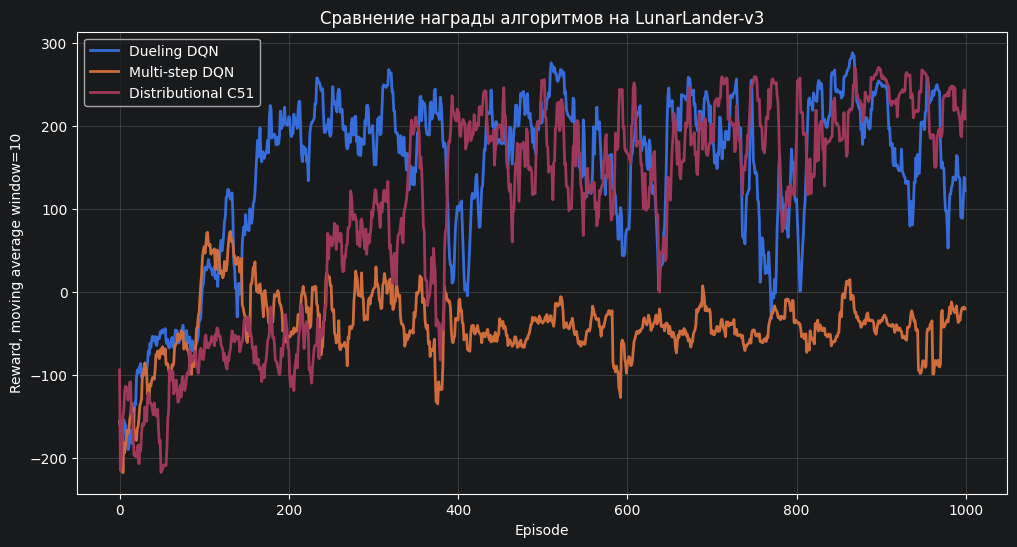

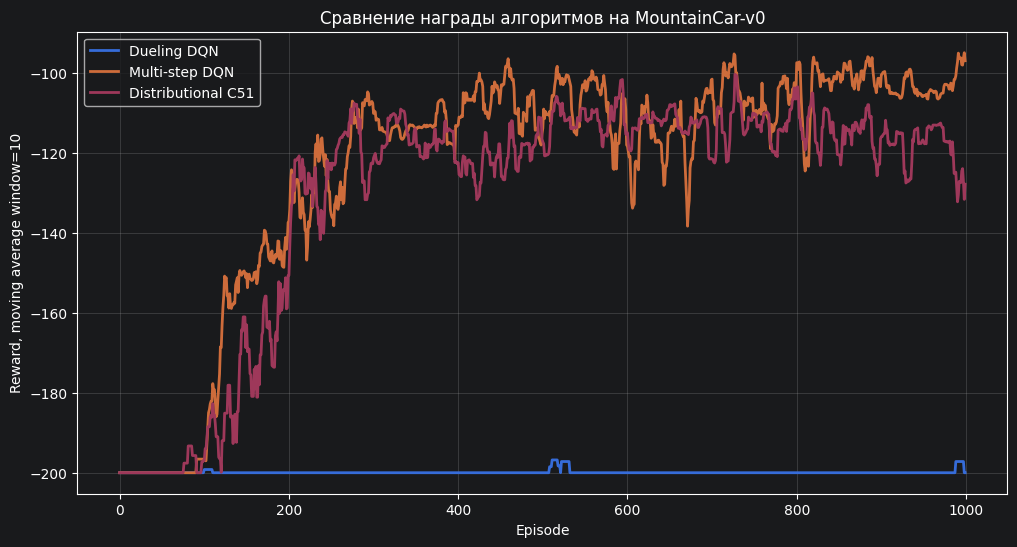

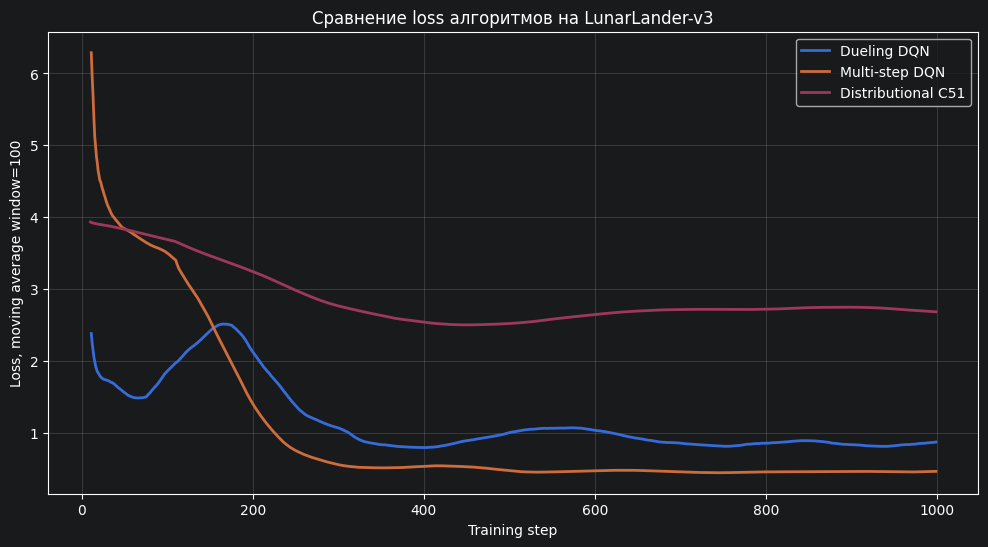

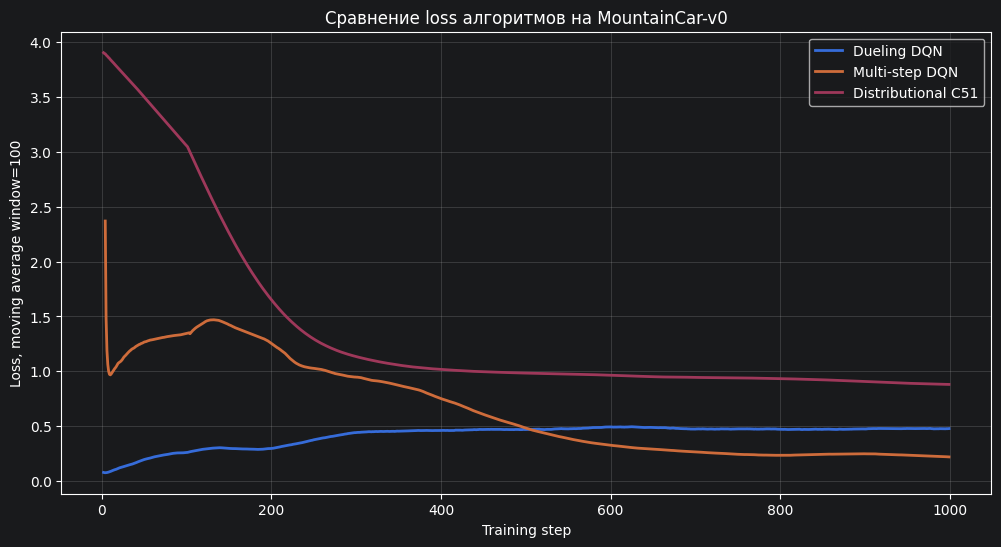

,Environment,Algorithm,Mean last 20,Best reward
2,LunarLander-v3,Distributional C51,215.377700,318.386568
0,LunarLander-v3,Dueling DQN,143.075783,320.163982
1,LunarLander-v3,Multi-step DQN,-18.725038,267.481086
4,MountainCar-v0,Multi-step DQN,-97.800000,-83.000000
5,MountainCar-v0,Distributional C51,-128.100000,-84.000000
3,MountainCar-v0,Dueling DQN,-198.600000,-172.000000


In [30]:
def plot_algorithm_comparison(all_results, smoothing_window=10):
    for env_name, env_results in all_results.items():
        plt.figure(figsize=(12, 6))

        for alg_name, result in env_results.items():
            ma = moving_average(result["rewards"], smoothing_window)
            plt.plot(ma, label=alg_name, linewidth=2)

        plt.title(f"Сравнение награды алгоритмов на {env_name}")
        plt.xlabel("Episode")
        plt.ylabel(f"Reward, moving average window={smoothing_window}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


def plot_loss_comparison(all_results, smoothing_window=100):
    for env_name, env_results in all_results.items():
        plt.figure(figsize=(12, 6))
        has_losses = False

        for alg_name, result in env_results.items():
            losses = result.get("losses", [])

            if losses is None or len(losses) == 0:
                continue

            loss_ma = moving_average(losses, smoothing_window)
            plt.plot(loss_ma, label=alg_name, linewidth=2)
            has_losses = True

        if not has_losses:
            plt.close()
            print(f"Для {env_name} нет данных loss.")
            continue

        plt.title(f"Сравнение loss алгоритмов на {env_name}")
        plt.xlabel("Training step")
        plt.ylabel(f"Loss, moving average window={smoothing_window}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


plot_algorithm_comparison(all_results, smoothing_window=SMOOTHING_WINDOW)
plot_loss_comparison(all_results, smoothing_window=100)

summary_df.sort_values(["Environment", "Mean last 20"], ascending=[True, False])

## Таблица гиперпараметров

In [31]:
params_rows = []
for env_name, algorithms in BEST_CONFIGS.items():
    for alg_name, cfg in algorithms.items():
        row = {
            "Environment": env_name,
            "Algorithm": alg_name,
            "lr": cfg["lr"],
            "gamma": cfg["gamma"],
            "batch_size": cfg["batch_size"],
            "epsilon_start": cfg["epsilon_start"],
            "epsilon_min": cfg["epsilon_min"],
            "epsilon_decay": cfg["epsilon_decay"],
            "target_update_freq": cfg["target_update_freq"],
            "learning_starts": cfg["learning_starts"],
            "buffer_capacity": cfg["buffer_capacity"],
            "architecture": cfg.get("hidden_sizes", cfg.get("hidden_layers")),
            "n_step": cfg.get("n_step", None),
            "num_atoms": cfg.get("num_atoms", None),
            "v_min": cfg.get("v_min", None),
            "v_max": cfg.get("v_max", None),
            "reward_shaping": cfg.get("reward_shaping", False),
            "normalize_state": cfg.get("normalize_state", False),
            "c51_reward_shaping": cfg.get("c51_reward_shaping", False),
        }
        params_rows.append(row)

params_df = pd.DataFrame(params_rows)
params_df


,Environment,Algorithm,lr,gamma,batch_size,epsilon_start,epsilon_min,epsilon_decay,target_update_freq,learning_starts,buffer_capacity,architecture,n_step,num_atoms,v_min,v_max,reward_shaping,normalize_state,c51_reward_shaping
0,LunarLander-v3,Dueling DQN,0.0005,0.99,128,1.0,0.01,0.990,100,1000,50000,"(128, 128)",1.0,NaN,NaN,NaN,False,False,False
1,LunarLander-v3,Multi-step DQN,0.0005,0.95,128,1.0,0.01,0.990,200,1000,50000,"(128, 128)",3.0,NaN,NaN,NaN,False,False,False
2,LunarLander-v3,Distributional C51,0.0005,0.99,64,1.0,0.05,0.995,200,1000,100000,"(128,)",NaN,51.0,-200.0,200.0,False,False,False
3,MountainCar-v0,Dueling DQN,0.0010,0.99,128,1.0,0.03,0.995,100,500,50000,"(128, 128)",1.0,NaN,NaN,NaN,True,False,False
4,MountainCar-v0,Multi-step DQN,0.0020,0.99,256,1.0,0.01,0.990,50,1000,50000,"(128, 128)",3.0,NaN,NaN,NaN,True,False,False
5,MountainCar-v0,Distributional C51,0.0005,0.95,128,1.0,0.01,0.990,500,500,100000,"(128,)",NaN,51.0,-200.0,0.0,False,True,True
